In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import time

In [6]:
# Load dataset
X, y = load_digits(return_X_y=True)

In [8]:
# --- PCA ---
start = time.time()
X_pca = PCA(n_components=2).fit_transform(X)
print(f"Elapsed: {time.time()-start:.3f} s")

Elapsed: 0.003 s


In [9]:
# --- t-SNE ---
start = time.time()
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X)
print(f"Elapsed: {time.time()-start:.3f} s")

Elapsed: 3.474 s


In [10]:
# --- UMAP ---
start = time.time()
X_umap = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X)
print(f"Elapsed: {time.time()-start:.3f} s")

/home/jovyan/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Elapsed: 7.647 s


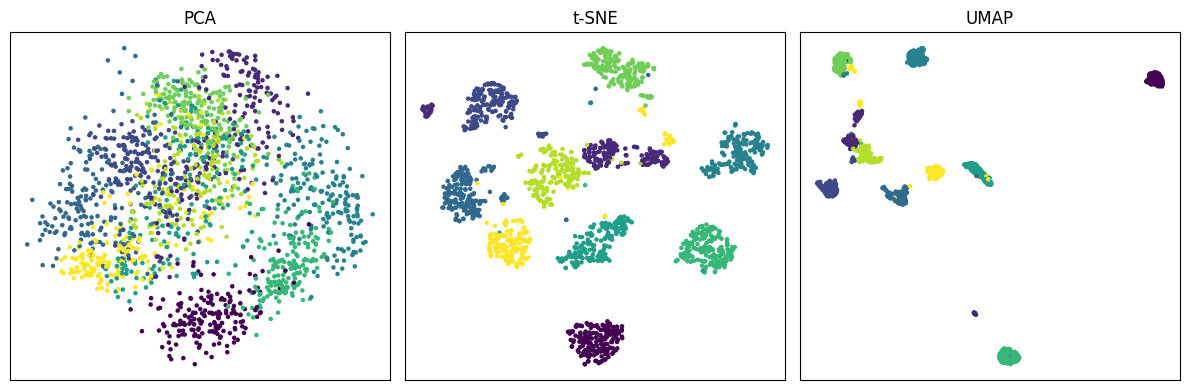

In [11]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, X_emb, title in zip(axes, [X_pca, X_tsne, X_umap],["PCA", "t-SNE", "UMAP"]):
    sc = ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y, s=5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("comparacion_dim_red.png")
plt.show()
